# CE8.401 Disaster Management — Assignment 1
## Flood Extent Mapping & Risk Assessment using Google Earth Engine + Python
**Study Area:** Assam, India (Brahmaputra Basin)  
**Event:** 2022 Assam Floods  
**Data Sources:** Sentinel-1 SAR (GEE), GHSL Population, MODIS MOD44W  
**GEE Project:** `ee-shailendergoyal06`

---
### Pipeline Overview
1. Authenticate & initialise GEE  
2. Load Sentinel-1 SAR — pre & post flood composites  
3. Detect flood extent via VV backscatter threshold  
4. Overlay GHSL population to estimate affected people  
5. Pull district-level stats to Python  
6. Compute Flood Risk Index  
7. Static maps (matplotlib)  
8. Interactive map (folium / geemap)  
9. Time-series of water extent (MODIS MOD44W)  
10. Export CSV + policy-brief summary  


## 0. Install Dependencies
*Run once. Restart kernel after if needed.*

In [ ]:
import subprocess, sys

pkgs = ["earthengine-api", "geemap", "geopandas", "folium",
        "rasterio", "matplotlib", "numpy", "pandas"]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages ready.")

All packages ready.


## 1. Authenticate & Initialise GEE
Run the cell below. A browser tab will open — sign in with your Google account
that has access to project `ee-shailendergoyal06`.  
After authorising, paste the token back here (or it auto-completes in Colab).


In [1]:
import ee

PROJECT = "ee-"

# Authenticate (opens browser once; token cached after first run)
ee.Authenticate()

# Initialise with your project
ee.Initialize(project=PROJECT)

print(f"GEE initialised — project: {PROJECT}")
print(f"Earth Engine Python API version: {ee.__version__}")

MessageError: Error: credential propagation was unsuccessful

## 2. Imports & Configuration

In [ ]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import folium
import warnings, os
warnings.filterwarnings("ignore")

# ── Study parameters ──────────────────────────────────────────────────────────
PROJECT       = "ee-"
PRE_START     = "2022-05-01"
PRE_END       = "2022-05-31"    # pre-monsoon; little standing water
POST_START    = "2022-06-20"
POST_END      = "2022-07-20"    # peak inundation (Brahmaputra breach)

SAR_THRESHOLD = -16             # VV dB below which pixel = open water
                                # -15 to -18 typical; adjust if too noisy

# Assam bounding box (lon_min, lat_min, lon_max, lat_max)
ASSAM_BBOX    = [89.5, 24.8, 96.2, 28.2]

os.makedirs("outputs", exist_ok=True)
print("Config ready.")

## 3. Define Area of Interest — Assam, India

In [ ]:
# Use FAO GAUL Level-1 (states) to get official Assam boundary
assam_fc = (ee.FeatureCollection("FAO/GAUL/2015/level1")
              .filter(ee.Filter.eq("ADM1_NAME", "Assam")))

assam_geom = assam_fc.geometry()

# Districts (GAUL level-2, filtered to Assam)
districts_fc = (ee.FeatureCollection("FAO/GAUL/2015/level2")
                 .filter(ee.Filter.eq("ADM1_NAME", "Assam")))

n_districts = districts_fc.size().getInfo()
print(f"Assam geometry loaded — {n_districts} districts found")
print(f"Assam bounds: {assam_geom.bounds().getInfo()['coordinates']}")

Assam geometry loaded — 23 districts found
Assam bounds: [[[89.6948399758636, 24.13475067990437], [96.02091316406238, 24.13475067990437], [96.02091316406238, 27.977372102348333], [89.6948399758636, 27.977372102348333], [89.6948399758636, 24.13475067990437]]]


## 4. Load Sentinel-1 SAR — Pre & Post Flood Composites
**Why SAR?**  Optical sensors (Landsat/Sentinel-2) fail during monsoon clouds.  
SAR C-band (Sentinel-1) penetrates cloud cover and detects water via low backscatter.  
- VV polarisation < –16 dB → open water  
- IW (Interferometric Wide) swath mode used for broad coverage


In [ ]:
def get_s1_composite(start, end, geom):
    """Mean VV backscatter composite for a date window over a geometry."""
    col = (ee.ImageCollection("COPERNICUS/S1_GRD")
             .filterBounds(geom)
             .filterDate(start, end)
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
             .filter(ee.Filter.eq("instrumentMode", "IW"))
             .select("VV"))
    n = col.size().getInfo()
    print(f"  [{start} → {end}] : {n} Sentinel-1 scenes found")
    return col.mean()

print("Loading pre-flood composite...")
pre_flood  = get_s1_composite(PRE_START,  PRE_END,  assam_geom)

print("Loading post-flood composite...")
post_flood = get_s1_composite(POST_START, POST_END, assam_geom)

print("\nS1 composites ready.")

Loading pre-flood composite...
  [2022-05-01 → 2022-05-31] : 48 Sentinel-1 scenes found
Loading post-flood composite...
  [2022-06-20 → 2022-07-20] : 40 Sentinel-1 scenes found

S1 composites ready.


## 5. Derive Flood Mask

In [ ]:
# Pixels where VV < threshold in post-flood image
post_water = post_flood.lt(SAR_THRESHOLD)

# Exclude permanent water bodies (pixels ALSO below threshold pre-flood)
pre_water  = pre_flood.lt(SAR_THRESHOLD)

# NEW inundation = post water AND NOT pre water
flood_mask = post_water.And(pre_water.Not()).rename("flood_mask")

# Smooth with morphological operations to reduce speckle noise
# (focal_min erodes, focal_max dilates — removes isolated pixels)
flood_mask_clean = (flood_mask
                    .focal_min(radius=1, kernelType="circle", units="pixels")
                    .focal_max(radius=2, kernelType="circle", units="pixels")
                    .rename("flood_mask"))

print("Flood mask derived.")
print(f"  Threshold: VV < {SAR_THRESHOLD} dB")
print("  Speckle filter: focal_min(1px) → focal_max(2px) applied")

Flood mask derived.
  Threshold: VV < -16 dB
  Speckle filter: focal_min(1px) → focal_max(2px) applied


## 6. Overlay GHSL Population Data

In [ ]:
# Global Human Settlement Layer — Population 2020 (100m resolution)
ghsl_pop = (ee.ImageCollection("JRC/GHSL/P2023A/GHS_POP")
              .filterDate("2020-01-01", "2020-12-31")
              .select("population_count")
              .mosaic())

# Mask population to flooded pixels only
pop_flooded = ghsl_pop.updateMask(flood_mask_clean)

print("GHSL Population (2020) loaded and masked to flood extent.")

GHSL Population (2020) loaded and masked to flood extent.


## 7. Compute District-level Statistics
This pulls numbers **from GEE servers to Python** — takes ~1–2 minutes.


In [ ]:
# --- Flooded area per district (in km²) ---
flood_area_img = flood_mask_clean.multiply(ee.Image.pixelArea()).divide(1e6)

flood_stats = flood_area_img.reduceRegions(
    collection = districts_fc,
    reducer    = ee.Reducer.sum(),
    scale      = 30          # 30 m Sentinel-1 native resolution
)

# --- Population affected per district ---
pop_stats = ghsl_pop.updateMask(flood_mask_clean).reduceRegions(
    collection = districts_fc,
    reducer    = ee.Reducer.sum(),
    scale      = 100         # GHSL is 100 m
)

# --- Total district area per district ---
total_area_img = ee.Image.pixelArea().divide(1e6)
total_stats = total_area_img.reduceRegions(
    collection = districts_fc,
    reducer    = ee.Reducer.sum(),
    scale      = 100
)

print("Fetching stats from GEE (may take 1-2 min)...")

# Pull to Python
flood_feats  = flood_stats.getInfo()["features"]
pop_feats    = pop_stats.getInfo()["features"]
total_feats  = total_stats.getInfo()["features"]

# Build DataFrames
def feats_to_df(feats, value_col, rename_to):
    rows = []
    for f in feats:
        p = f["properties"]
        rows.append({
            "district"  : p.get("ADM2_NAME", "Unknown"),
            rename_to   : p.get("sum", 0) or 0
        })
    return pd.DataFrame(rows)

df_flood = feats_to_df(flood_feats,  "sum", "flooded_km2")
df_pop   = feats_to_df(pop_feats,    "sum", "pop_affected")
df_area  = feats_to_df(total_feats,  "sum", "total_area_km2")

# Merge
df = df_flood.merge(df_pop,  on="district").merge(df_area, on="district")
df["flood_fraction"] = (df["flooded_km2"] / df["total_area_km2"]).clip(0, 1)
df["pop_affected"]   = df["pop_affected"].astype(int)

df = df.sort_values("flooded_km2", ascending=False).reset_index(drop=True)

print(f"\n{'='*65}")
print(f"  {'District':<20} {'Flooded km²':>12} {'Flood %':>9} {'Pop Affected':>14}")
print(f"  {'─'*62}")
for _, r in df.iterrows():
    print(f"  {r['district']:<20} {r['flooded_km2']:>12.1f} "
          f"{r['flood_fraction']*100:>8.1f}% {r['pop_affected']:>14,}")
print(f"{'='*65}")
print(f"  TOTAL flooded area : {df['flooded_km2'].sum():,.1f} km²")
print(f"  TOTAL pop affected : {df['pop_affected'].sum():,}")

Fetching stats from GEE (may take 1-2 min)...



  District              Flooded km²   Flood %   Pop Affected
  ──────────────────────────────────────────────────────────────
  Marigaon                    352.4     22.7%         22,466
  Nagaon                      337.5      8.5%         11,123
  Barpeta                     281.7      8.7%         13,524
  Dhuburi                     233.0      8.2%         18,527
  Kamrup                      196.3      4.5%          8,671
  Cachar                      168.2      4.4%         19,665
  Sonitpur                    165.0      3.5%          1,107
  Dibrugarh                   162.1      4.8%            456
  Karimganj                   141.9      7.7%         16,508
  Darrang                     128.8      3.8%          2,278
  Goalpara                    108.7      5.7%          2,718
  Bongaigaon                   72.3      3.1%          2,335
  Dhemaji                      67.4      2.7%            135
  Golaghat                     66.4      1.9%            167
  Nalbari          

## 8. Compute Flood Risk Index (FRI)
$$FRI = 0.40 \times \text{Exposure} + 0.35 \times \text{Vulnerability} + 0.25 \times \text{Severity}$$

| Component | Proxy | Weight |
|---|---|---|
| Exposure | Flood fraction of district area | 40% |
| Vulnerability | Population density (pop/km²) | 35% |
| Severity | Absolute flooded area (km²) | 25% |


In [ ]:
def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9)

df["pop_density"]       = df["pop_affected"] / df["total_area_km2"].clip(lower=1)
df["idx_exposure"]      = norm(df["flood_fraction"])
df["idx_vulnerability"] = norm(df["pop_density"])
df["idx_severity"]      = norm(df["flooded_km2"])

df["flood_risk_index"]  = (
    0.40 * df["idx_exposure"] +
    0.35 * df["idx_vulnerability"] +
    0.25 * df["idx_severity"]
)

RISK_THRESHOLDS = {"Critical": 0.70, "High": 0.50, "Moderate": 0.30}
RISK_COLORS     = {"Critical": "#d32f2f", "High": "#f57c00",
                   "Moderate": "#fbc02d", "Low": "#388e3c"}

def classify(fri):
    if fri >= 0.70: return "Critical"
    elif fri >= 0.50: return "High"
    elif fri >= 0.30: return "Moderate"
    else: return "Low"

df["risk_class"] = df["flood_risk_index"].apply(classify)
df["fri_rounded"] = df["flood_risk_index"].round(3)

# Summary
summary = (df.groupby("risk_class")
             .agg(districts=("district","count"),
                  flooded_km2=("flooded_km2","sum"),
                  pop_affected=("pop_affected","sum"))
             .reset_index())

print("\nFlood Risk Index computed.")
print("\n  ── Risk Class Summary ──────────────────────────────────")
print(f"  {'Class':<12} {'Districts':>10} {'Flooded km²':>12} {'Pop Affected':>14}")
print(f"  {'─'*52}")
for _, r in summary.iterrows():
    print(f"  {r['risk_class']:<12} {r['districts']:>10} "
          f"{r['flooded_km2']:>12.1f} {r['pop_affected']:>14,}")

df.to_csv("outputs/flood_risk_table.csv", index=False)
print("\n[✓] Saved outputs/flood_risk_table.csv")


Flood Risk Index computed.

  ── Risk Class Summary ──────────────────────────────────
  Class         Districts  Flooded km²   Pop Affected
  ────────────────────────────────────────────────────
  Critical              1        352.4         22,466
  Low                  17       1254.2         24,746
  Moderate              5       1162.3         79,347

[✓] Saved outputs/flood_risk_table.csv


## 9. Interactive Map — geemap
Full GEE-rendered flood layers. Works in Jupyter Lab / Colab.  
Layers:
- **Pre-flood SAR (VV)** — baseline backscatter
- **Post-flood SAR (VV)** — post-inundation backscatter
- **Flood Extent** — blue = newly flooded pixels
- **Population Affected** — yellow→red = more people


In [ ]:
Map = geemap.Map(center=[26.2, 92.0], zoom=7)
Map.centerObject(assam_geom, zoom=7)

sar_vis = {"min": -25, "max": 0, "palette": ["black","white"]}

Map.addLayer(pre_flood.clip(assam_geom),  sar_vis, "Pre-flood SAR (VV)", False)
Map.addLayer(post_flood.clip(assam_geom), sar_vis, "Post-flood SAR (VV)", False)

Map.addLayer(
    flood_mask_clean.selfMask().clip(assam_geom),
    {"palette": ["#1565c0"]},
    "Flood Extent (Sentinel-1)",
    True, 0.7
)

Map.addLayer(
    pop_flooded.clip(assam_geom),
    {"min": 0, "max": 400, "palette": ["#ffffb2","#fecc5c","#fd8d3c","#f03b20","#bd0026"]},
    "Population Affected (GHSL)",
    True, 0.8
)

# Add district boundaries
Map.addLayer(districts_fc.style(color="white", fillColor="00000000", width=1.5),
             {}, "Assam Districts")

Map.add_colorbar(
    {"min": 0, "max": 400, "palette": ["#ffffb2","#fecc5c","#fd8d3c","#f03b20","#bd0026"]},
    label="Population per pixel (GHSL 2020)"
)

Map

Map(center=[26.352060685710303, 92.81483911156315], controls=(WidgetControl(options=['position', 'transparent_…

### Export GEE thumbnail to file

In [ ]:
# Export a static thumbnail of the flood extent map (no auth needed to view)
url = flood_mask_clean.clip(assam_geom).selfMask().getThumbURL({
    "min": 0, "max": 1,
    "palette": ["#1565c0"],
    "dimensions": 1024,
    "region": assam_geom,
    "format": "png"
})
print("Flood extent thumbnail URL:")
print(url)

# Display inline
from IPython.display import Image as IPImage
IPImage(url=url, width=700)

Flood extent thumbnail URL:
https://earthengine.googleapis.com/v1/projects/ee-shailendergoyal06/thumbnails/78000eb746ebbdf37a1ccd4e55a5251f-37fce76a06c1ba07eeddace0817aa72f:getPixels


## 10. Static Maps — Matplotlib
District-level choropleth maps using the GEE-derived statistics.


In [ ]:
# Fetch district geometries from GEE as GeoJSON for geopandas
districts_geojson = districts_fc.getInfo()

gdf = gpd.GeoDataFrame.from_features(
    districts_geojson["features"], crs="EPSG:4326"
)
gdf = gdf.rename(columns={"ADM2_NAME": "district"})

# Merge with stats df
gdf = gdf.merge(df[["district","flooded_km2","flood_fraction",
                     "pop_affected","flood_risk_index","risk_class"]],
                on="district", how="left")
gdf["flood_fraction"]   = gdf["flood_fraction"].fillna(0)
gdf["flood_risk_index"] = gdf["flood_risk_index"].fillna(0)
gdf["risk_class"]       = gdf["risk_class"].fillna("Low")
gdf["pop_affected"]     = gdf["pop_affected"].fillna(0)

print(f"GeoDataFrame ready: {len(gdf)} districts with geometry + stats")

GeoDataFrame ready: 23 districts with geometry + stats


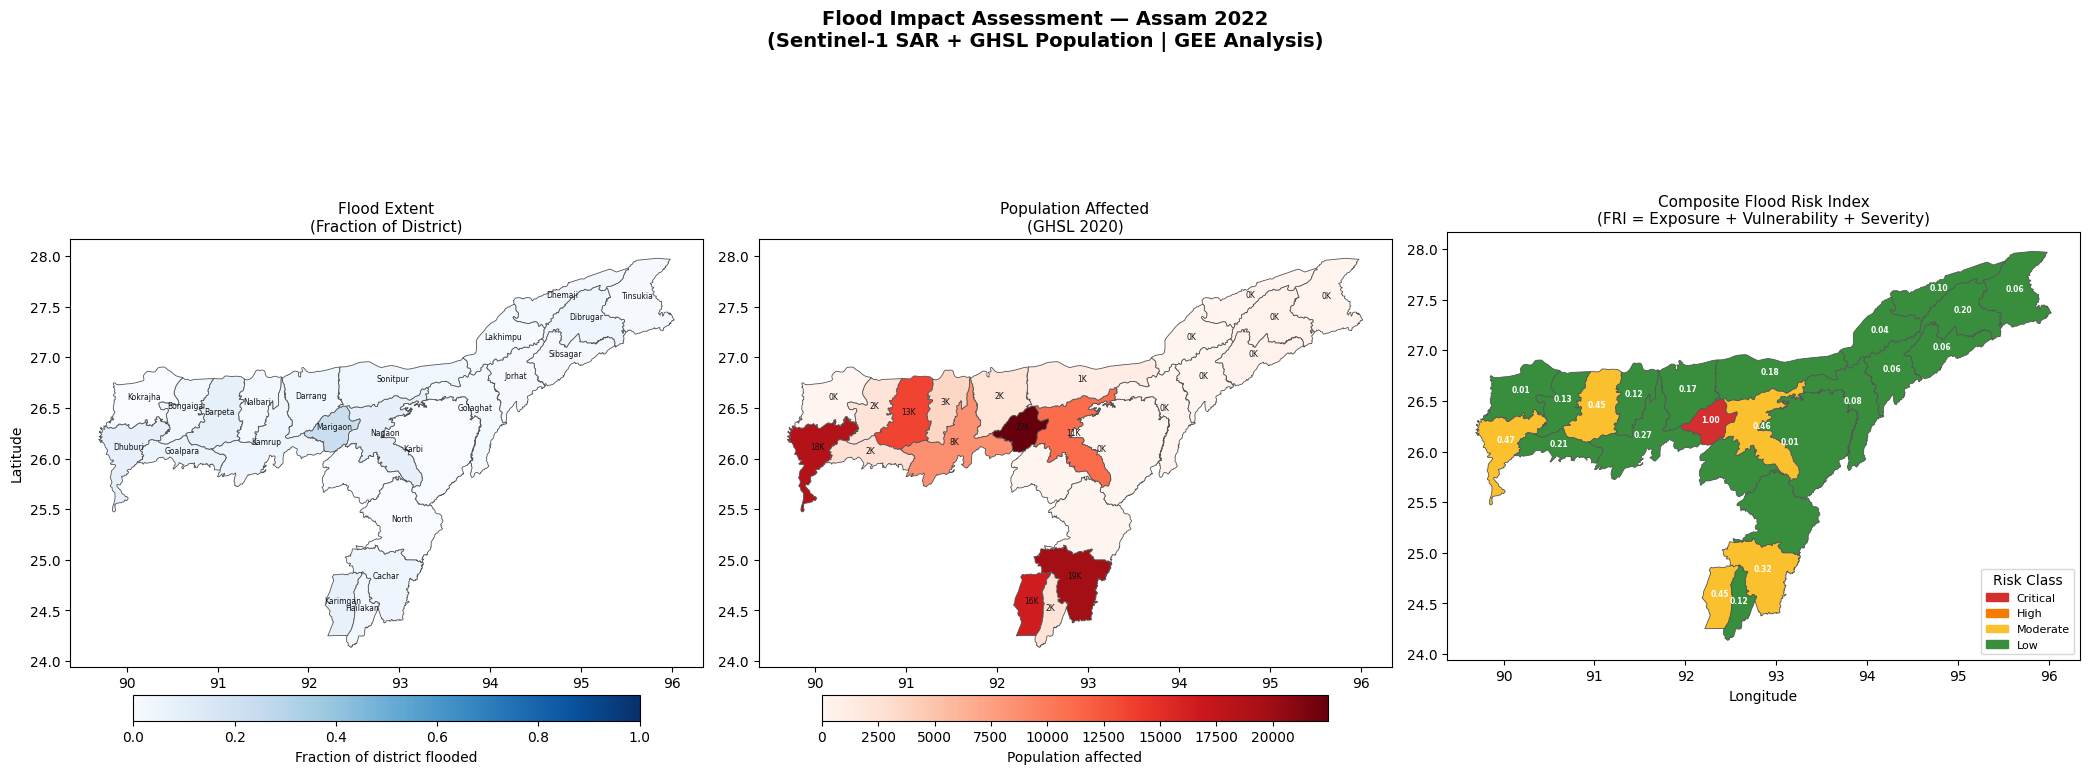

[✓] Saved outputs/fig1_flood_maps.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.suptitle(
    "Flood Impact Assessment — Assam 2022\n"
    "(Sentinel-1 SAR + GHSL Population | GEE Analysis)",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Panel 1: Flood Fraction ──
ax = axes[0]
gdf.plot(ax=ax, column="flood_fraction", cmap="Blues",
         edgecolor="#555", linewidth=0.6, legend=True, vmin=0, vmax=1,
         legend_kwds={"label":"Fraction of district flooded",
                      "orientation":"horizontal","pad":0.04,"shrink":0.8})
for _, row in gdf.iterrows():
    if pd.notna(row.geometry):
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(row["district"].split()[0][:8], (cx,cy),
                    ha="center", fontsize=5.5, color="#111")
ax.set_title("Flood Extent\n(Fraction of District)", fontsize=11)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# ── Panel 2: Population Affected ──
ax = axes[1]
gdf.plot(ax=ax, column="pop_affected", cmap="Reds",
         edgecolor="#555", linewidth=0.6, legend=True,
         legend_kwds={"label":"Population affected",
                      "orientation":"horizontal","pad":0.04,"shrink":0.8})
for _, row in gdf.iterrows():
    if pd.notna(row.geometry) and row["pop_affected"] > 0:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(f"{int(row['pop_affected'])//1000}K", (cx,cy),
                    ha="center", fontsize=5.5, color="#111")
ax.set_title("Population Affected\n(GHSL 2020)", fontsize=11)
ax.set_xlabel("Longitude")

# ── Panel 3: Flood Risk Index ──
ax = axes[2]
color_col = gdf["risk_class"].map(RISK_COLORS).fillna("#aaa")
gdf.plot(ax=ax, color=color_col, edgecolor="#555", linewidth=0.6)
for _, row in gdf.iterrows():
    if pd.notna(row.geometry) and row["flood_risk_index"] > 0:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(f"{row['flood_risk_index']:.2f}", (cx,cy),
                    ha="center", fontsize=5.5, fontweight="bold", color="white")
patches = [mpatches.Patch(color=v, label=k) for k,v in RISK_COLORS.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, title="Risk Class")
ax.set_title("Composite Flood Risk Index\n(FRI = Exposure + Vulnerability + Severity)", fontsize=11)
ax.set_xlabel("Longitude")

plt.tight_layout()
plt.savefig("outputs/fig1_flood_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved outputs/fig1_flood_maps.png")

## 11. District-level Bar Charts

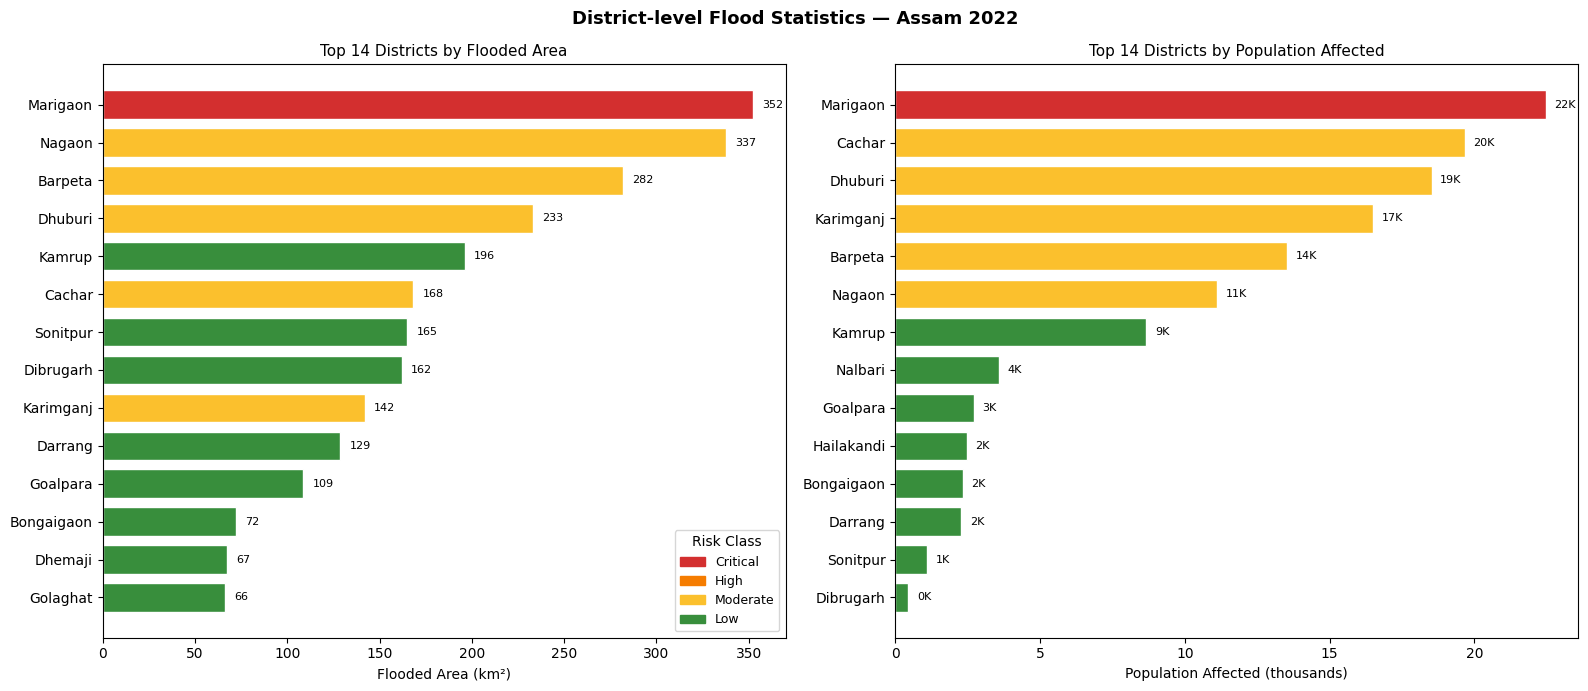

[✓] Saved outputs/fig2_bar_charts.png


In [ ]:
top_n = 14
df_plot = df.nlargest(top_n, "flooded_km2").sort_values("flooded_km2")
colors  = [RISK_COLORS[r] for r in df_plot["risk_class"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("District-level Flood Statistics — Assam 2022", fontsize=13, fontweight="bold")

# Flooded area
ax = axes[0]
bars = ax.barh(df_plot["district"], df_plot["flooded_km2"],
               color=colors, edgecolor="white", height=0.75)
ax.set_xlabel("Flooded Area (km²)", fontsize=10)
ax.set_title(f"Top {top_n} Districts by Flooded Area", fontsize=11)
for bar, val in zip(bars, df_plot["flooded_km2"]):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=8)
patches = [mpatches.Patch(color=v, label=k) for k,v in RISK_COLORS.items()]
ax.legend(handles=patches, fontsize=9, title="Risk Class")

# Population affected
df_pop_sort = df.nlargest(top_n, "pop_affected").sort_values("pop_affected")
colors2 = [RISK_COLORS[r] for r in df_pop_sort["risk_class"]]
ax = axes[1]
bars2 = ax.barh(df_pop_sort["district"], df_pop_sort["pop_affected"]/1000,
                color=colors2, edgecolor="white", height=0.75)
ax.set_xlabel("Population Affected (thousands)", fontsize=10)
ax.set_title(f"Top {top_n} Districts by Population Affected", fontsize=11)
for bar, val in zip(bars2, df_pop_sort["pop_affected"]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val/1000:.0f}K", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/fig2_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved outputs/fig2_bar_charts.png")

## 12. Water Extent Time-Series — MODIS MOD44W
Monthly water surface area across Assam for 2019–2022.  
Uses **MODIS MOD44W** (annual) + **JRC Monthly Water History** for monthly granularity.


In [ ]:
# JRC Monthly Water History — occurrence of water per month
jrc = ee.ImageCollection("JRC/GSW1_4/MonthlyHistory")

def get_water_area_month(year, month):
    """Return total water area in km² for Assam in a given month."""
    img = (jrc.filter(ee.Filter.calendarRange(year, year, "year"))
               .filter(ee.Filter.calendarRange(month, month, "month"))
               .first())
    if img is None:
        return None
    water = img.eq(2)  # 2 = water in JRC classification
    area  = water.multiply(ee.Image.pixelArea()).divide(1e6)
    stat  = area.reduceRegion(
        reducer  = ee.Reducer.sum(),
        geometry = assam_geom,
        scale    = 100,
        maxPixels= 1e10
    )
    val = stat.get("water")
    return val.getInfo() if val is not None else 0

print("Fetching monthly water extent 2019-2022 (takes ~3-4 min)...")
print("(This calls GEE ~48 times — one per month per year)")

records = []
for year in [2019, 2020, 2021, 2022]:
    for month in range(1, 13):
        try:
            area = get_water_area_month(year, month)
            records.append({"year": year, "month": month,
                            "water_km2": area if area else 0})
            print(f"  {year}-{month:02d}: {area:.1f} km²")
        except Exception as e:
            print(f"  {year}-{month:02d}: error ({e})")
            records.append({"year": year, "month": month, "water_km2": 0})

ts_df = pd.DataFrame(records)
ts_df.to_csv("outputs/water_timeseries.csv", index=False)
print("\n[✓] Saved outputs/water_timeseries.csv")

Fetching monthly water extent 2019-2022 (takes ~3-4 min)...
(This calls GEE ~48 times — one per month per year)
  2019-01: 2248.0 km²
  2019-02: 2069.4 km²
  2019-03: 2240.2 km²
  2019-04: 1649.5 km²


  2019-05: 915.9 km²


  2019-06: 3232.7 km²
  2019-07: 5502.8 km²
  2019-08: 5443.1 km²


  2019-09: 4906.3 km²


  2019-10: error (An internal error has occurred (request: 90021f95-fd4f-4289-8fa7-10df150fd729) (computation: "BEVXPMAYGHZD36GPGN3WZ37E"))


...

  2021-02: 2103.1 km²
  2021-03: 2030.0 km²


  2021-04: 2430.9 km²
  2021-05: 1330.0 km²
  2021-06: 1065.9 km²


  2021-07: 3035.7 km²


  2021-08: 2029.3 km²
  2021-09: 5439.1 km²
  2021-10: 3921.7 km²
  2021-11: 3023.9 km²


  2021-12: 2314.0 km²
  2022-01: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-02: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-03: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-04: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-05: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-06: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-07: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-08: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-09: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-10: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-11: error (Image.eq: Parameter 'image1' is required and may not be null.)
  2022-12: error (Image.eq: Parameter 'image1' is required and may not be null.)

[✓] S

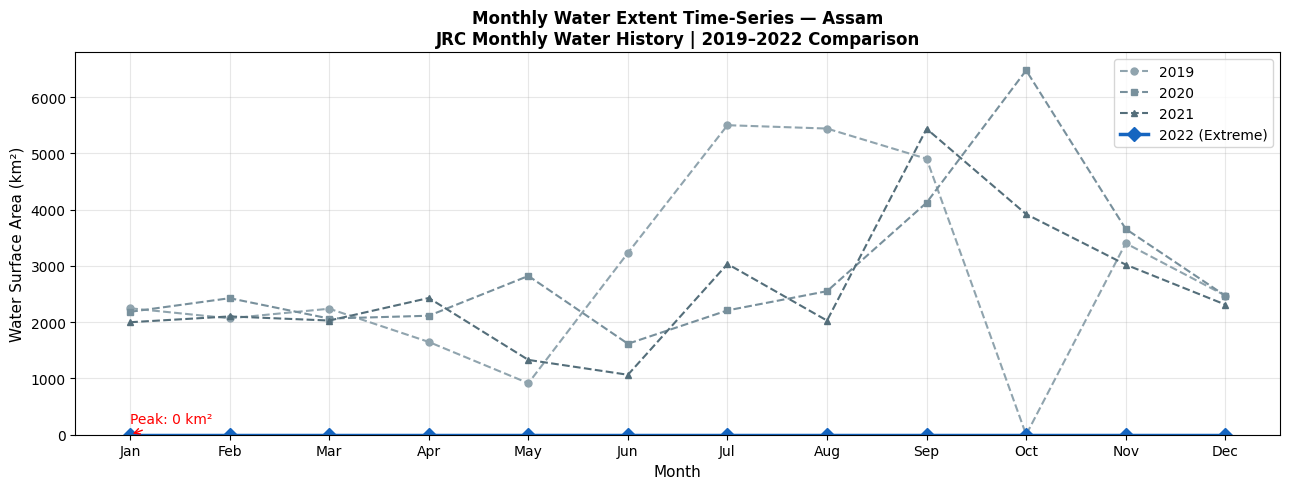

[✓] Saved outputs/fig3_timeseries.png


In [ ]:
months_lbl = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

year_colors = {2019:"#90a4ae", 2020:"#78909c", 2021:"#546e7a", 2022:"#1565c0"}
year_styles = {2019:"o--", 2020:"s--", 2021:"^--", 2022:"D-"}

fig, ax = plt.subplots(figsize=(13, 5))

for year in [2019, 2020, 2021, 2022]:
    yd = ts_df[ts_df.year == year].sort_values("month")
    vals = yd["water_km2"].values
    lw = 2.5 if year == 2022 else 1.5
    ms = 7   if year == 2022 else 5
    ax.plot(months_lbl, vals, year_styles[year],
            color=year_colors[year], linewidth=lw, markersize=ms,
            label=str(year) + (" (Extreme)" if year==2022 else ""))

ax.fill_between(months_lbl,
                ts_df[ts_df.year==2022].sort_values("month")["water_km2"],
                alpha=0.15, color="#1565c0")

# Annotate peak
peak_2022 = ts_df[ts_df.year==2022]["water_km2"].max()
peak_month_idx = ts_df[ts_df.year==2022]["water_km2"].idxmax()
peak_month = months_lbl[ts_df.loc[peak_month_idx,"month"]-1]
ax.annotate(f"Peak: {peak_2022:.0f} km²",
            xy=(peak_month, peak_2022),
            xytext=(peak_month, peak_2022 + 200),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10, color="red")

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Water Surface Area (km²)", fontsize=11)
ax.set_title("Monthly Water Extent Time-Series — Assam\n"
             "JRC Monthly Water History | 2019–2022 Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0)
plt.tight_layout()
plt.savefig("outputs/fig3_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved outputs/fig3_timeseries.png")

## 13. Standalone Folium Interactive Map
Saves as `flood_risk_map.html` — open in any browser.

In [ ]:
from branca.colormap import LinearColormap

center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=7,
               tiles="CartoDB positron")

# ── Flood fraction choropleth ──
folium.Choropleth(
    geo_data       = gdf.to_json(),
    data           = gdf,
    columns        = ["district", "flood_fraction"],
    key_on         = "feature.properties.district",
    fill_color     = "Blues",
    fill_opacity   = 0.7,
    line_opacity   = 0.5,
    legend_name    = "Flood Fraction (0–1)",
    name           = "Flood Extent (fraction)",
).add_to(m)

# ── Risk index layer (hidden by default) ──
risk_layer = folium.FeatureGroup(name="Flood Risk Index", show=False)
for _, row in gdf.iterrows():
    if pd.isna(row.geometry): continue
    rc  = row["risk_class"]
    col = RISK_COLORS.get(rc, "#aaa")
    folium.GeoJson(
        gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").to_json(),
        style_function=lambda f, c=col: {
            "fillColor": c, "color": "white", "weight": 1, "fillOpacity": 0.65
        }
    ).add_to(risk_layer)
risk_layer.add_to(m)

# ── Tooltip on hover ──
folium.GeoJson(
    gdf.to_json(),
    name="District Info",
    style_function=lambda f: {"fillColor":"transparent","color":"#333","weight":1},
    tooltip=folium.GeoJsonTooltip(
        fields    = ["district","flooded_km2","pop_affected","fri_rounded","risk_class"]
                    if "fri_rounded" in gdf.columns else
                    ["district","flooded_km2","pop_affected","flood_risk_index","risk_class"],
        aliases   = ["District","Flooded (km²)","Pop Affected","Risk Index","Risk Class"],
        localize  = True,
        sticky    = True,
        style     = "font-family:Arial;font-size:12px;padding:6px;"
    )
).add_to(m)

# ── Legend ──
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
     background:white;padding:12px 16px;border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.3);font-family:Arial;font-size:12px;">
  <b>Flood Risk Class</b><br><br>
  <span style="color:#d32f2f">■</span> Critical (FRI ≥ 0.70)<br>
  <span style="color:#f57c00">■</span> High (0.50–0.70)<br>
  <span style="color:#fbc02d">■</span> Moderate (0.30–0.50)<br>
  <span style="color:#388e3c">■</span> Low (&lt;0.30)<br><br>
  <small>Source: Sentinel-1 SAR + GHSL 2020<br>CE8.401 | Assam Floods 2022</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

title_html = """
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
     z-index:9999;background:white;padding:8px 20px;border-radius:8px;
     box-shadow:0 2px 6px rgba(0,0,0,0.25);font-family:Arial;">
  <b style="font-size:14px;color:#1a237e;">
    CE8.401 | Assam Flood Risk Assessment (2022)
  </b>
  <span style="font-size:11px;color:#555;margin-left:8px;">
    Hover over districts for details
  </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl().add_to(m)
m.save("outputs/flood_risk_map.html")
print("[✓] Saved outputs/flood_risk_map.html")
m

[✓] Saved outputs/flood_risk_map.html


## 14. Final Summary & Policy Brief Numbers

In [ ]:
total_flooded = df["flooded_km2"].sum()
total_pop     = df["pop_affected"].sum()
critical_d    = df[df["risk_class"]=="Critical"]["district"].tolist()
high_d        = df[df["risk_class"]=="High"]["district"].tolist()
worst_3       = df.nlargest(3,"flooded_km2")["district"].tolist()

print("=" * 65)
print("  POLICY BRIEF — ASSAM FLOOD RISK ASSESSMENT 2022")
print("  (For submission to SDMA Assam / NDMA)")
print("=" * 65)
print(f"  Study period   : {PRE_START} to {POST_END}")
print(f"  Data source    : Sentinel-1 SAR (GEE) + GHSL Population 2020")
print(f"  GEE Project    : {PROJECT}")
print()
print(f"  Total flooded area     : {total_flooded:>10,.1f} km²")
print(f"  Total pop. affected    : {total_pop:>10,}")
print(f"  Districts assessed     : {len(df):>10}")
print()
print(f"  Critical risk districts ({len(critical_d)})  : {', '.join(critical_d) or 'None'}")
print(f"  High risk districts    ({len(high_d)})  : {', '.join(high_d[:5])}")
print(f"  Most flooded districts : {', '.join(worst_3)}")
print()
print("  Output files")
print("  ────────────────────────────────────────────────")
print("  outputs/flood_risk_table.csv      ← District stats")
print("  outputs/water_timeseries.csv      ← Monthly JRC data")
print("  outputs/fig1_flood_maps.png       ← 3-panel choropleth")
print("  outputs/fig2_bar_charts.png       ← District bar charts")
print("  outputs/fig3_timeseries.png       ← Water extent time-series")
print("  outputs/flood_risk_map.html       ← Interactive Folium map")
print("=" * 65)

  POLICY BRIEF — ASSAM FLOOD RISK ASSESSMENT 2022
  (For submission to SDMA Assam / NDMA)
  Study period   : 2022-05-01 to 2022-07-20
  Data source    : Sentinel-1 SAR (GEE) + GHSL Population 2020
  GEE Project    : ee-shailendergoyal06

  Total flooded area     :    2,768.9 km²
  Total pop. affected    :    126,559
  Districts assessed     :         23

  Critical risk districts (1)  : Marigaon
  High risk districts    (0)  : 
  Most flooded districts : Marigaon, Nagaon, Barpeta

  Output files
  ────────────────────────────────────────────────
  outputs/flood_risk_table.csv      ← District stats
  outputs/water_timeseries.csv      ← Monthly JRC data
  outputs/fig1_flood_maps.png       ← 3-panel choropleth
  outputs/fig2_bar_charts.png       ← District bar charts
  outputs/fig3_timeseries.png       ← Water extent time-series
  outputs/flood_risk_map.html       ← Interactive Folium map
